# 🌊 BinWaves Duke (Validation)

> **Inputs:**
> - `Kp_coefficients.nc` file saved in the `outputs/` folder, obtained with the `Propagation Notebook`
> - OPTIONAL: buoy_buoy_ID_bulk_parameters.pkl`: wave bulk parameters (Hs, Tp, Dp) stored in the `inputs/buoy_data/` folder.
>
>
> **Outputs:**
> - PLosty.
> - `Kp_coefficients.nc` file saved in the `outputs/` folder.

### BinWaves Notebooks Overview

This Jupyter Notebook is the first of three in the **BinWaves** modeling workflow, following Cagigal et al., 2024 :

1. `BinWaves_Propagation.ipynb`  
2. `BinWaves_Reconstruction.ipynb`  
3. `BinWaves_Validation.ipynb`

---

#### Before You Start

Make sure you have:

- Installed the latest version of `bluemath-tk`:  
  ```bash
  pip install bluemath-tk

- **BlueMath Toolkit Repository**:  [https://github.com/GeoOcean/BlueMath_tk.git](https://github.com/GeoOcean/BlueMath_tk.git)

Before continuing, ensure you have **created and activated a Python environment**.

*** Other Required Packages ***
- `wavespectra` 
- `cartophy`
 
---

<details>
<summary><strong>📁 BinWaves_Propagation.ipynb</strong></summary>

This notebook constructs the **library of pre-run cases** for all **monochromatic wave systems**.

##### Requirements:

- A **bathymetry** file placed in the `inputs/` folder, in the correct format.

If you don't have a specific bathymetry file for your study area, you can:

- **Download GEBCO bathymetry data** (~400 m resolution):  [https://download.gebco.net/](https://download.gebco.net/)


</details>

---

<details>
<summary><strong>📁 BinWaves_Reconstruction.ipynb</strong></summary>

This notebook reconstructs **wave conditions** using **offshore directional wave spectra**.

##### Requirements:

- Offshore wave spectrum data (e.g., **CAWCR** or **ERA5** datasets).

- **OPTIONAL 1**: Apply **satellite corrections** to the hindcast spectrum before running BinWaves using the `CalVal` tool in the BlueMath toolkit. An example is provided in the Jupyter Notebook **Satellite Correction**.

- **OPTIONAL 2**: A **Super Point Spectrum** can be also used as input to the hindcast spectrum before running BinWaves. The `SuperPoint` aggregates the energy from a number of points (Wave Spectra) surrounding the study site (Cagigal et al., 2021).  An example is provided in the Jupyter Notebook **Super Point Computation** .

</details>

---

<details open>
<summary><strong>📁 BinWaves_Validation.ipynb</strong></summary>

This notebook performs **validation** using **wave buoy data**, if available.

##### Requirements:

- Wave buoy data in a format compatible with BinWaves (if available).
- Some wave buoy data can be freely downloaded from:  
  🌊 [https://www.ndbc.noaa.gov/](https://www.ndbc.noaa.gov/)

- **NOTE:** You can use the `NDBC_buoy_data.ipynb` notebook to:
  - Download the buoy data.
  - Convert it into the appropriate format for BinWaves.

</details>

In [1]:
import xarray as xr
import numpy as np
import pandas as pd
import os
import os.path as op

In [2]:
cawcr_spectrum = xr.open_dataset('inputs/4469_spec_satellite_corrected.nc')
cawcr_spectrum

<xarray.Dataset> Size: 2GB
Dimensions:    (time: 405963, freq: 29, dir: 24)
Coordinates:
  * time       (time) datetime64[ns] 3MB 1979-01-01 ... 2025-04-01
    station    int32 4B ...
  * freq       (freq) float32 116B 0.035 0.0385 0.04235 ... 0.4171 0.4589 0.5047
  * dir        (dir) float32 96B 7.5 22.5 37.5 52.5 ... 307.5 322.5 337.5 352.5
Data variables:
    efth       (time, freq, dir) float64 2GB ...
    Depth      (time) float32 2MB ...
    Wspeed     (time) float32 2MB ...
    Wdir       (time) float32 2MB ...
    longitude  (time) float32 2MB ...
    latitude   (time) float32 2MB ...

In [3]:

buoys = {
    "44088": (-74.8390, 36.6120),
    "44100": (-75.5930, 36.2580),
    "44086": (-75.4210, 36.0010),
    "44056": (-75.7140, 36.2000),
    "44095": (-75.3300, 35.7500),
    "41120": (-75.2850, 35.2580),
    "41025": (-75.4540, 35.0100),
    "41159": (-76.9440, 34.2110),
    "41110": (-77.7150, 34.1420),
    "41013": (-77.7640, 33.4410),
    "41108": (-78.0160, 33.7210),
}


def find_site_index(kp_coeffs, target_x, target_y, tolerance=1.0):
    """
    Find the site index in kp_coeffs that matches the target coordinates.

    Parameters:
    -----------
    kp_coeffs : xarray.Dataset
        The kp coefficients dataset
    target_x : float
        Target coord_x coordinate
    target_y : float
        Target coord_y coordinate
    tolerance : float
        Tolerance for coordinate

    Returns:
    --------
    int
        The site index that matches the coordinates
    """
    # Get all site coordinates
    site_x = kp_coeffs.coord_x.values
    site_y = kp_coeffs.coord_y.values

    # Calculate distances to all sites
    distances = np.sqrt((site_x - target_x) ** 2 + (site_y - target_y) ** 2)

    # Find the site with minimum distance
    site_index = np.argmin(distances)

    # Check if the closest site is within tolerance
    if distances[site_index] > tolerance:
        print(f"Warning: Closest site is {distances[site_index]:.2f} away")

    return site_index


def load_buoy_data(buoy_id, year=None):
    """
    Load buoy data and return both the wave data and location coordinates.

    Parameters:
    -----------
    buoy_id : str
        The buoy ID (e.g., '44100')
    year : str, optional
        The year to filter data for (default: None)

    Returns:
    --------
    tuple
        (buoy_waves, buoy_location, kp_coeffs)
    """
    # Load buoy data
    buoy_waves = pd.read_pickle(
        f"inputs/buoy_data/buoy_{buoy_id}_bulk_parameters.pkl"
    ).sort_index()
    if year:
        buoy_waves = buoy_waves.loc[year]
    buoy_waves = buoy_waves.dropna(subset=["Hs_Buoy", "Tp_Buoy", "Dir_Buoy"])
    buoy_location = buoys[buoy_id]

    # Load kp coefficients
    kp_coeffs = xr.open_dataset("outputs/kp_coefficients.nc")
    site_index = find_site_index(kp_coeffs, buoy_location[0], buoy_location[1])
    kp_coeffs = kp_coeffs.isel(site=[site_index])

    return buoy_waves, buoy_location, kp_coeffs, site_index

buoy_id = "44056"  
buoy_waves, buoy_location, kp_coeffs , site_index= load_buoy_data(buoy_id, year="2023")

print(f"Buoy {buoy_id} coordinates:")
print(f"WGS84: {buoy_location[0]}, {buoy_location[1]}")
print(f"\nSelected kp_coeffs site coordinates:")
print(f"{kp_coeffs.coord_x.values}, {kp_coeffs.coord_y.values}")

Buoy 44056 coordinates:
WGS84: -75.714, 36.2

Selected kp_coeffs site coordinates:
[-75.714], [36.2]


In [4]:
from utils.operations import transform_Offshore_spectrum

model_parameters = pd.read_csv("CASES/swan_cases.csv").to_dict(orient="list")

# Load interest spectra
offshore_spectra, offshore_spectra_case = transform_Offshore_spectrum(
    CAWCR_spectrum=cawcr_spectrum,
    subset_parameters=model_parameters,
    available_case_num=kp_coeffs.case_num.values,
    fixed_direction=True, # True if efth is already in degrees(no radians) and cawcr direction for wavespectra  already corrected (from -> to)'
)
offshore_spectra_case

<xarray.DataArray 'efth' (case_num: 696, time: 405963)> Size: 2GB
array([[0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 0.00000000e+00, 2.50572768e-19],
       ...,
       [0.00000000e+00, 6.01560369e-27, 2.46071238e-22, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 3.80762353e-27, 0.00000000e+00, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 7.06916985e-25, 8.06842138e-23, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00]],
      shape=(696, 405963))
Coordinates:
  * case_num  (case_num) int64 6kB 0 1 2 3 4 5 6 ... 689 690 691 692 693 694 695
  * time      (time) datetime64[ns] 3MB 1979-01-01 ... 2025-04-01
    station   int32 4B 133

In [5]:

from bluemath_tk.waves.binwaves import reconstruc_spectra

# Remove duplicates from offshore_spectra_case
_, unique_idx_offshore_case = np.unique(offshore_spectra_case.time, return_index=True)
offshore_spectra_case = offshore_spectra_case.isel(time=unique_idx_offshore_case)

# Remove duplicates from offshore_spectra_case
_, unique_idx_offshore = np.unique(offshore_spectra.time, return_index=True)
offshore_spectra= offshore_spectra.isel(time=unique_idx_offshore)

# Make sure buoy_waves has unique indices
buoy_waves = buoy_waves[~buoy_waves.index.duplicated(keep="first")]

reconstructed_onshore_spectra = reconstruc_spectra(
    offshore_spectra=offshore_spectra_case.sel(time=buoy_waves.index, method="nearest"),
    kp_coeffs=kp_coeffs,
    num_workers=15,
)
reconstructed_onshore_spectra

/home/grupos/geocean/montanoj/miniforge3/envs/bluemath-fork/lib/python3.11/site-packages/distributed/node.py:187: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 34283 instead
  warnings.warn(
/home/grupos/geocean/montanoj/miniforge3/envs/bluemath-fork/lib/python3.11/site-packages/distributed/client.py:3371: UserWarning: Sending large graph of size 44.70 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


<xarray.Dataset> Size: 47MB
Dimensions:  (site: 1, freq: 29, dir: 24, time: 8397)
Coordinates:
  * site     (site) int64 8B 134
  * freq     (freq) float64 232B 0.035 0.0385 0.0423 ... 0.4171 0.4589 0.5047
  * dir      (dir) float64 192B 7.5 22.5 37.5 52.5 ... 307.5 322.5 337.5 352.5
    lat      float64 8B 0.0
    lon      float64 8B 0.0
    coord_x  (site) float64 8B -75.71
    coord_y  (site) float64 8B 36.2
  * time     (time) datetime64[ns] 67kB 2023-01-01 ... 2023-12-17T23:00:00.00...
    station  int32 4B 133
Data variables:
    kps      (time, site, freq, dir) float64 47MB 0.0 0.0 0.0 ... 0.0 0.0 0.0

/home/grupos/geocean/montanoj/miniforge3/envs/bluemath-fork/lib/python3.11/site-packages/xarray/plot/dataarray_plot.py:512: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  primitive = ax.plot(xplt_val, yplt_val, *args, **kwargs)
/home/grupos/geocean/montanoj/miniforge3/envs/bluemath-fork/lib/python3.11/site-packages/xarray/plot/dataarray_plot.py:512: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  primitive = ax.plot(xplt_val, yplt_val, *args, **kwargs)


Time series plot saved as: outputs/Figures/timeseries_Wave Validation 44056.png
Scatter plot saved as: outputs/Figures/scatter_Wave Validation 44056.png


(<Figure size 2000x1000 with 3 Axes>,
 array([<Axes: xlabel='time', ylabel='Hs [m]'>,
        <Axes: xlabel='time', ylabel='T [s] - tp'>,
        <Axes: ylabel='Dir [°] - dm'>], dtype=object),
 <Figure size 1500x500 with 3 Axes>,
 array([<Axes: xlabel='Hs - Buoy [m]', ylabel='Hs - BinWaves [m]'>,
        <Axes: xlabel='Tp - Buoy [s]', ylabel='Tp - BinWaves [s]'>,
        <Axes: xlabel='Dir - Buoy [°]', ylabel='Dir - BinWaves [°]'>],
       dtype=object))

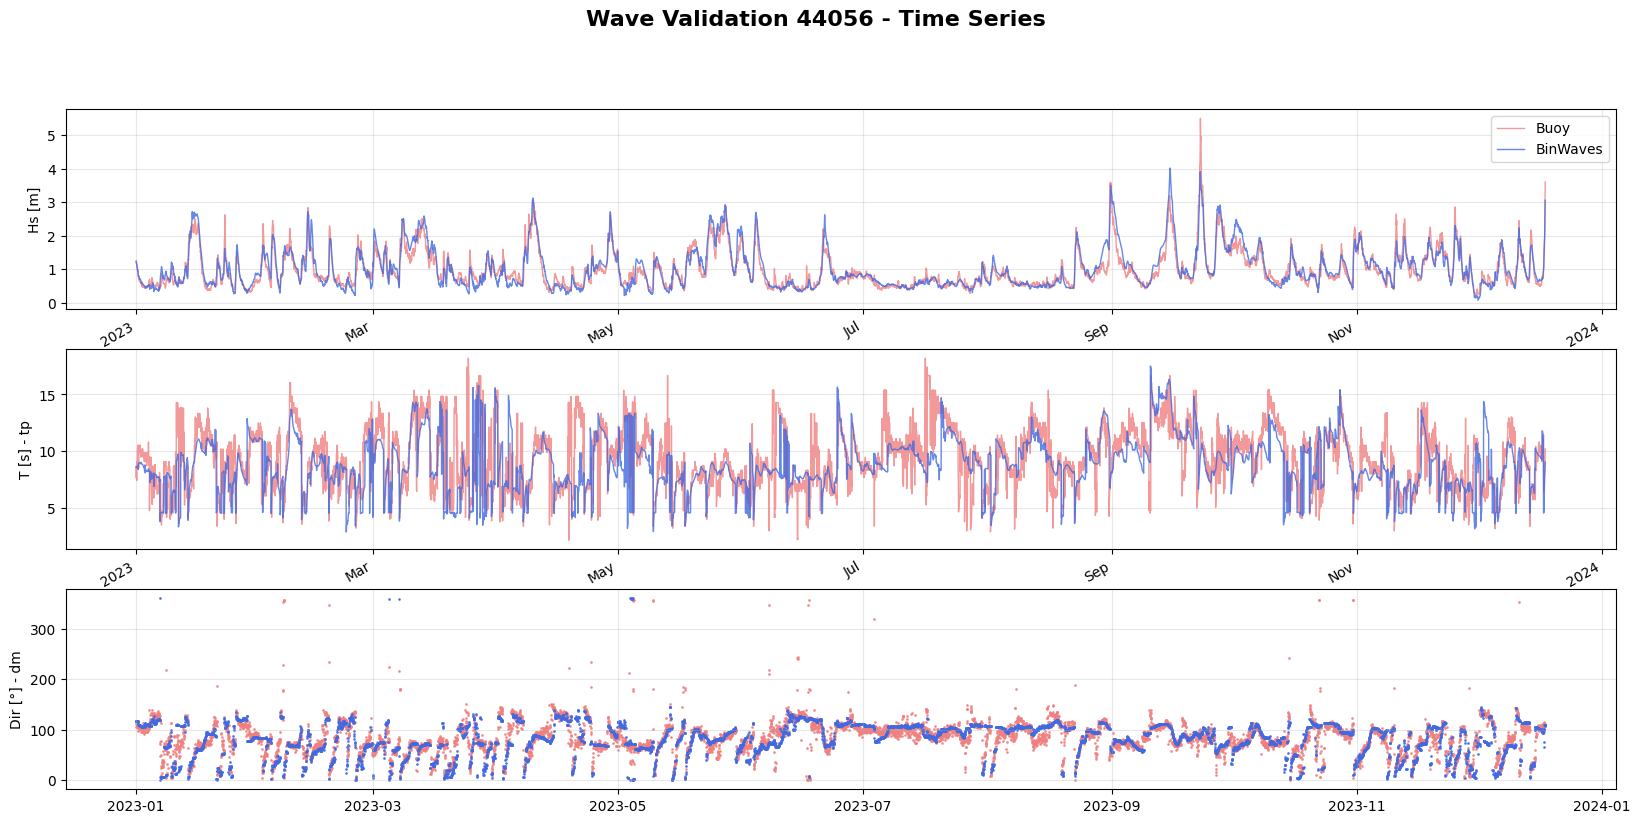

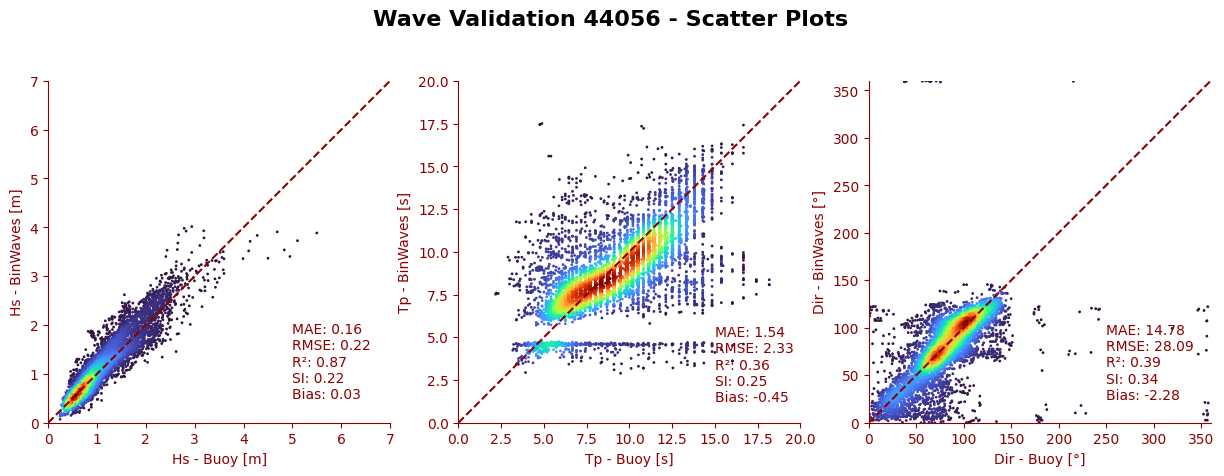

In [6]:
from utils.plotting import plot_wave_series

plot_wave_series(
    buoy_data=buoy_waves,
    binwaves_data=reconstructed_onshore_spectra.sel(
        time=buoy_waves.index, method="nearest"
    )
    .rename({"kps": "efth"})
    .squeeze()
    .spec,
    offshore_data=offshore_spectra.sel(time=buoy_waves.index, method="nearest").spec,
    times=buoy_waves.index.values,
    save_plots=True,
    save_path="outputs/Figures/",
    title_prefix="Wave Validation "+ buoy_id,
)